In [3]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.model import ECG_CNN1D

dispositivo = torch.device('cpu')  # Grad-CAM sobre un solo ejemplo no necesita GPU

CLASES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

In [4]:
modelo = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
modelo.load_state_dict(torch.load('../models/mejor_modelo.pt', map_location=dispositivo, weights_only=True))
modelo.eval()

# Queremos "espiar" justo después de la última capa ReLU del bloque3,
# antes de que el AdaptiveAvgPool1d comprima toda la información temporal.
# Recuerda la arquitectura: bloque3 = [Conv1d, BatchNorm1d, ReLU, AdaptiveAvgPool1d]
capa_objetivo = modelo.bloque3[2]

from src.gradcam import GradCAM1D
gradcam = GradCAM1D(modelo, capa_objetivo)

In [5]:
from torch.utils.data import DataLoader
from src.dataset import ECGDataset
from src.train import evaluar
from src.losses import FocalLossMultiLabel

X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

test_dataset = ECGDataset('../data/processed/X_test.npy', '../data/processed/y_test.npy')
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

_, predicciones_test, etiquetas_test = evaluar(modelo, test_loader, FocalLossMultiLabel(), dispositivo)

In [6]:
indice_clase = CLASES.index('HYP')

positivos_reales = np.where(etiquetas_test[:, indice_clase] == 1)[0]
probas_de_esos_casos = predicciones_test[positivos_reales, indice_clase]
idx_ejemplo = positivos_reales[np.argmax(probas_de_esos_casos)]

print(f"Índice del ejemplo elegido: {idx_ejemplo}")
print(f"Probabilidad predicha para HYP: {predicciones_test[idx_ejemplo, indice_clase]:.4f}")

Índice del ejemplo elegido: 1087
Probabilidad predicha para HYP: 0.6947


In [7]:
def graficar_gradcam(señal, cam, derivacion=1, nombre_clase='', probabilidad=None, ruta_guardado=None):
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.imshow(
        cam[np.newaxis, :], cmap='Reds', aspect='auto', alpha=0.5,
        extent=[0, len(cam), señal[:, derivacion].min(), señal[:, derivacion].max()]
    )
    ax.plot(señal[:, derivacion], color='black', linewidth=1.3)

    titulo = f'Grad-CAM — clase {nombre_clase}'
    if probabilidad is not None:
        titulo += f' (probabilidad predicha: {probabilidad:.2f})'
    ax.set_title(titulo)
    ax.set_xlabel('Muestras (tiempo)')
    ax.set_ylabel('Amplitud normalizada')

    if ruta_guardado:
        fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
    plt.show()

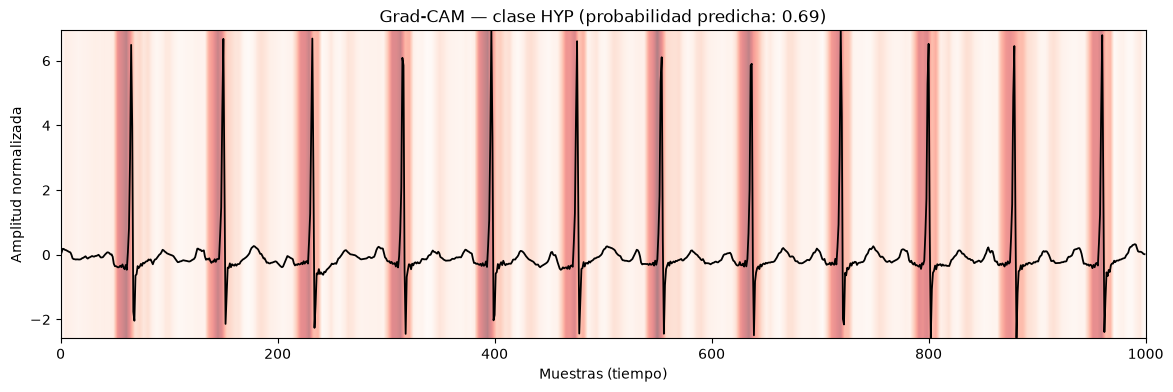

In [8]:
import os
os.makedirs('../assets', exist_ok=True)

señal_ejemplo = X_test[idx_ejemplo]  # forma (1000, 12), ya preprocesada
señal_tensor = torch.tensor(señal_ejemplo, dtype=torch.float32).transpose(0, 1)  # (12, 1000)

cam, probabilidad = gradcam.generar(señal_tensor, indice_clase)

graficar_gradcam(
    señal_ejemplo, cam,
    derivacion=1, nombre_clase='HYP', probabilidad=probabilidad,
    ruta_guardado='../assets/gradcam_hyp_ejemplo.png'
)

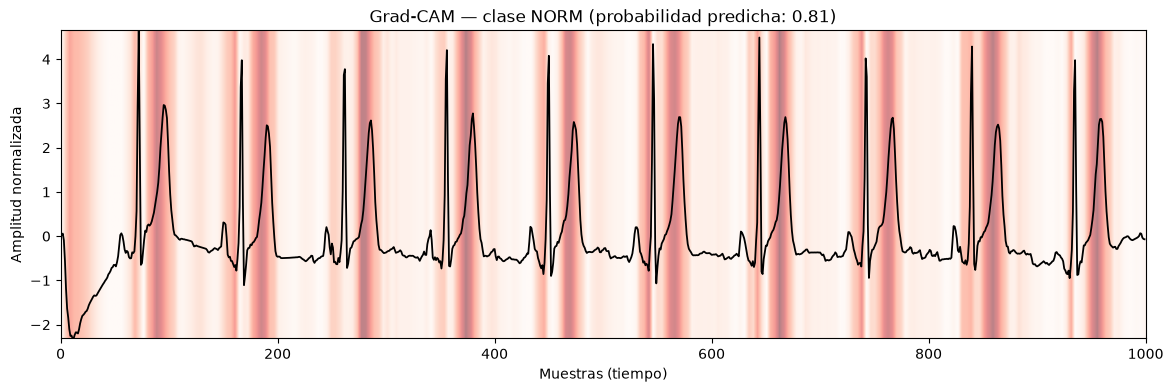

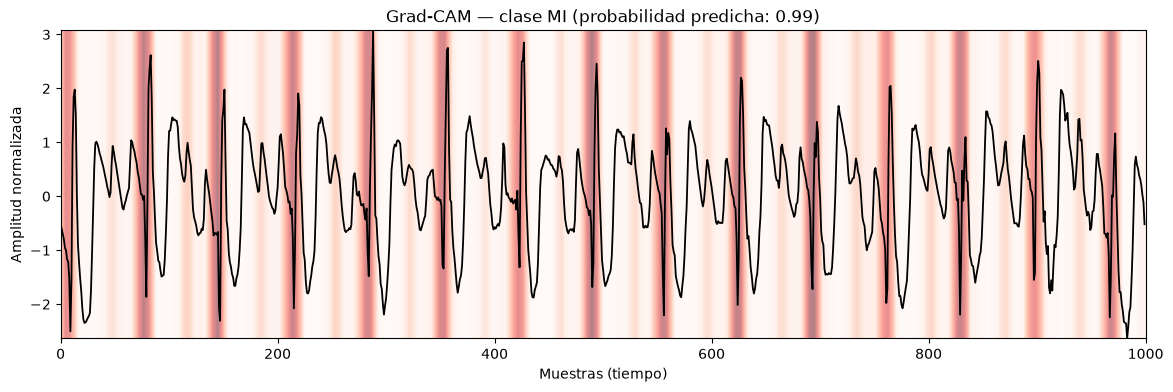

In [9]:
for nombre_clase in ['NORM', 'MI']:
    indice_clase = CLASES.index(nombre_clase)
    positivos_reales = np.where(etiquetas_test[:, indice_clase] == 1)[0]
    probas_de_esos_casos = predicciones_test[positivos_reales, indice_clase]
    idx_ejemplo = positivos_reales[np.argmax(probas_de_esos_casos)]

    señal_ejemplo = X_test[idx_ejemplo]
    señal_tensor = torch.tensor(señal_ejemplo, dtype=torch.float32).transpose(0, 1)
    cam, probabilidad = gradcam.generar(señal_tensor, indice_clase)

    graficar_gradcam(
        señal_ejemplo, cam,
        derivacion=1, nombre_clase=nombre_clase, probabilidad=probabilidad,
        ruta_guardado=f'../assets/gradcam_{nombre_clase.lower()}_ejemplo.png'
    )

In [10]:
from src.data_utils import cargar_metadatos_limpios

df = cargar_metadatos_limpios()

In [11]:
import requests
import wfdb

# Cogemos un ECG crudo real (sin preprocesar) del dataset
ecg_id_prueba = df.index[10]  # requiere haber cargado 'df' con cargar_metadatos_limpios()
ruta = '../data/' + df.loc[ecg_id_prueba, 'filename_lr']
record = wfdb.rdrecord(ruta)
señal_cruda = record.p_signal

respuesta = requests.post(
    "http://127.0.0.1:8000/predecir",
    json={"señal": señal_cruda.tolist()}
)
print(respuesta.json())

{'NORM': 0.6777, 'MI': 0.0714, 'STTC': 0.0705, 'CD': 0.1087, 'HYP': 0.1085}


In [12]:
import json
print(json.dumps({"señal": señal_cruda.tolist()}))

{"se\u00f1al": [[0.199, 0.084, -0.115, -0.142, 0.157, -0.015, -0.146, 0.038, 0.157, -0.038, 0.041, 0.127], [0.231, 0.085, -0.146, -0.158, 0.188, -0.031, -0.157, 0.065, 0.184, -0.009, 0.074, 0.159], [0.251, 0.089, -0.163, -0.17, 0.207, -0.037, -0.176, 0.092, 0.23, 0.039, 0.138, 0.216], [0.279, 0.087, -0.193, -0.183, 0.236, -0.053, -0.189, 0.089, 0.267, 0.082, 0.18, 0.262], [0.308, 0.121, -0.187, -0.214, 0.247, -0.032, -0.212, 0.077, 0.27, 0.102, 0.212, 0.287], [0.312, 0.143, -0.17, -0.227, 0.241, -0.013, -0.218, 0.064, 0.269, 0.092, 0.213, 0.294], [0.294, 0.114, -0.18, -0.204, 0.237, -0.033, -0.198, 0.037, 0.253, 0.09, 0.203, 0.291], [0.247, 0.068, -0.179, -0.157, 0.213, -0.056, -0.177, -0.01, 0.206, 0.07, 0.178, 0.247], [0.195, 0.019, -0.176, -0.106, 0.185, -0.078, -0.134, -0.065, 0.138, 0.001, 0.114, 0.176], [0.117, -0.05, -0.167, -0.034, 0.142, -0.108, -0.078, -0.12, 0.068, -0.067, 0.051, 0.113], [0.052, -0.107, -0.158, 0.028, 0.105, -0.132, -0.044, -0.171, 0.001, -0.122, -0.002, 0.0